In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [3]:
import random
import umap
from models.modules import *

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from scripts.run_model import *

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
############################################################

In [8]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [9]:
def process_fake_data():
    size = 20000
    x0 = sample_8gaussians(size).numpy()
    x1 = sample_moons(size).numpy()
    x = np.concatenate([x0, x1], axis = 0)
    adata = ad.AnnData(x)
    adata.obs['timepoint'] = pd.Categorical([0] * size + [1] * size)
    adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * (2 * size))
    adata.obsm['X_pca'] = adata.X
    adata.varm['PCs'] = np.zeros((2, 2))

    return adata, ['ctrl-inj']

In [10]:
def process_fake_time_data():
    size = 20000
    # x0 = torch.normal(0., 1., size=(size, 2))
    # x1 = sample_8gaussians(size).numpy()
    # x2 = sample_moons(size).numpy()
    x0 = 2 * sample_8gaussians(size).numpy()
    x1 = sample_8gaussians(size).numpy()
    x2 = sample_moons(size).numpy()
    x = np.concatenate([x0, x1, x2], axis = 0)
    adata = ad.AnnData(x)
    adata.obs['timepoint'] = pd.Categorical([0] * size + [1] * size + [2] * size)
    adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * (3 * size))
    adata.obsm['X_pca'] = adata.X
    adata.varm['PCs'] = np.zeros((2, 2))

    return adata, ['ctrl-inj']

In [11]:
############################################################

In [12]:
config = Config(
    {        
        # "model_class": "metricflow",
        "model_class": "flow",
        "max_epochs": 10000,
        "lr": 1e-3,
        "dropout": 0.0,
        "pc_dim": 2,
        "cond_dim": 2,
        "hidden_dim": 512,
        "batch_size": 512,
        "num_freq": 128,
        "num_layers": 4,
        "control_only": True,
        "force_cpu": False,
        "constrain": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 2,
        "accumulate_grad_batches": 1,
        "warmup_steps": 0,
        "ema_decay": None,
        "score_sigma": 0.5,

        "latent_dim": 256,

        "sigma": 0.1,
        "cfg_p_u": 0.0,
        "cfg_w": 1.0,
    }
)

project = "fm-ipynb"

In [13]:
wandb.finish()

In [14]:
small_fake = False

In [15]:
if small_fake:
    adata, values = process_fake_data()
else:
    adata, values = process_fake_time_data()
conditions, dataset = extract_dataset(adata, values)

In [16]:
model = run_model(config, project, adata, values, conditions, dataset)

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type   | Params | Mode 
--------------------------------------------
0 | flow_net | SinNet

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▇█▆▃▅▄▃▄▃▂▃▂▃▄█▃▅▆▃▁▄▃▃▂▂▃▄▃▂▆▄▂▅▄▂▃▃▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇█
epoch,9999
train_loss,1.48673
trainer/global_step,9999


In [17]:
for obj in dataset:
    X0, X1, t0, t1, gene_target = obj
    print(X0.shape, X1.shape, t0, t1, gene_target)

torch.Size([20000, 2]) torch.Size([20000, 2]) 0 1 ctrl-inj
torch.Size([20000, 2]) torch.Size([20000, 2]) 1 2 ctrl-inj


In [18]:
from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [19]:
num_samples = 1024
steps = 500
value = 'ctrl-inj'
c = conditions[value]
c = c.unsqueeze(0).repeat(num_samples, 1)

In [20]:
def sample_gaussians(size):
    return torch.normal(0., 1., size=(size, 2))

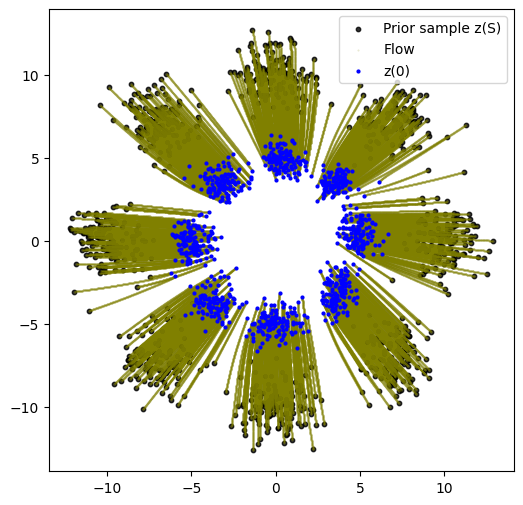

In [21]:
if not small_fake:
    x = 2 * sample_8gaussians(num_samples)
    traj = model.sample_traj(x.numpy(), c, 0, 1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [31]:
if not small_fake:
    x = sample_8gaussians(num_samples)
    traj = model.sample_traj(x.numpy(), c, 1, 2, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 4096 but got size 1024 for tensor number 1 in the list.

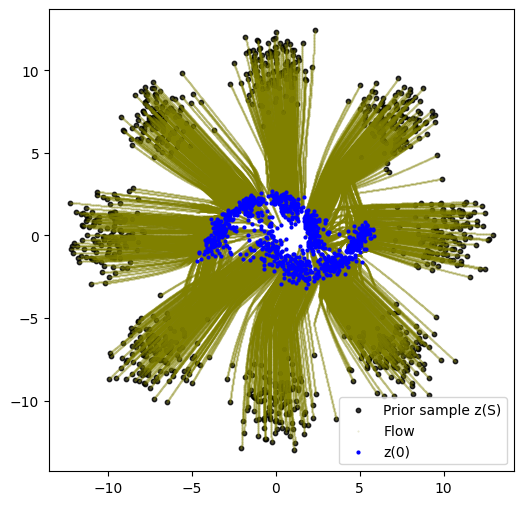

In [23]:
if not small_fake:
    x = 2 * sample_8gaussians(num_samples)
    traj = model.sample_traj(x.numpy(), c, 0, 2, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [24]:
if small_fake:
    x = sample_8gaussians(num_samples)
    traj = model.sample_traj(x.numpy(), c, 0, 1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [25]:
#################################

In [26]:
#################################

In [27]:
def visualize(model, samples):

    m = torch.max(torch.abs(samples))
    m += 1
    
    xs = torch.linspace(-m, m, steps=30)
    ys = torch.linspace(-m, m, steps=30)
    x, y = torch.meshgrid(xs, ys, indexing='xy')
    print(x.shape)
    print(y.shape)
    z = torch.stack([x, y], dim = -1).reshape(900, -1)

    print(z.shape)
    
    v = model(z).detach()

    fig, ax = plt.subplots()

    ax.scatter(samples[:,0], samples[:, 1])
    ax.quiver(z[:,0], z[:,1], v[:,0], v[:,1])
    plt.show()

In [28]:
config = Config(
    {        
        "model_class": "metricflow",
        "max_epochs": 500,
        "lr": 1e-3,
        "dropout": 0.0,
        "pc_dim": 2,
        "cond_dim": 2,
        "hidden_dim": 512,
        "batch_size": 512,
        "num_freq": 128,
        "num_layers": 4,
        "control_only": True,
        "force_cpu": False,
        "constrain": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 2,
        "accumulate_grad_batches": 1,
        "warmup_steps": 0,
        "ema_decay": None,
        "score_sigma": 0.5,

        "latent_dim": 256,

        "sigma": 0.1,
        "cfg_p_u": 0.0,
        "cfg_w": 1.0,
    }
)

project = "fm-ipynb"

In [29]:
wandb.finish()

In [30]:
conditions, dataset = extract_dataset(adata, values)
score_model, _, _ = run_full_model(config, project, adata, values, conditions, dataset)

AttributeError: <class 'wandb.sdk.wandb_config.Config'> object has no attribute 'score_max_epochs'

In [ ]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(score_model.score_net, samples)